<a href="https://colab.research.google.com/github/AI-Biotechnology-Bioinformatics/Drug_Discovery_AI_Course_2026/blob/main/QSAR_Part_4_Regression_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **AI And Biotechnology/Bioinformatics**

## **AI and Drug Discovery Course: QSAR Modeling**
This notebook demonstrates how to build **Random forest Regression model** to predict pIC50 values.

In [1]:
# @title
# Install LazyPredict
!pip install lazypredict


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 814.0/814.0 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 12.4 MB/s eta 0:00:00


In [2]:
# Install SHAP
!pip install shap

In [3]:
# Import libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.utils import shuffle
from lazypredict.Supervised import LazyRegressor
import shap

## **Loading the Dataset**

In [4]:
df = pd.read_csv('QSAR_dataset.csv')
df.head()

,molecule_chembl_id,bioactivity_class,pIC50,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,CHEMBL5821675,active,6.52,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,CHEMBL5979784,active,7.17,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,CHEMBL5930957,active,8.80,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,CHEMBL5969896,inactive,5.28,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,CHEMBL5612217,active,8.70,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## **Dataset overview:**
- `molecule_chembl_id`: Unique molecule ID
- `bioactivity_class`: Active/inactive class
- `pIC50`: Continuous potency value (4-9)
- `PubchemFP0` to `PubchemFP880`: 881 binary fingerprints

We have 2443 molecules and 881 features plus 3 identifier/target columns.

## **Features (X) and Target (y)**

Features are our PubChem fingerprints. Target is pIC50 for regression.
We'll exclude non-feature columns first.

In [5]:
# Exclude non-feature columns
non_feature_cols = ['molecule_chembl_id', 'bioactivity_class', 'pIC50']
X = df.drop(columns=non_feature_cols)
print(X.shape)

(2443, 881)


In [6]:
# Target variable
y_reg = df['pIC50']
y_reg

,pIC50
0,6.52
1,7.17
2,8.80
3,5.28
4,8.70
...,...
2438,9.29
2439,7.30
2440,4.78
2441,5.07


## **Feature Selection – Variance Threshold**

Not all 881 fingerprints are informative. Low-variance features (mostly 0 or 1) add noise. We remove them using `VarianceThreshold`.

In [7]:
# Apply variance threshold
selection = VarianceThreshold(threshold=(0.8*(1-0.8)))  # Threshold = 0.16
X_var = selection.fit_transform(X)

# Extract the correct feature names
selected_mask = selection.get_support()
feature_names = X.columns[selected_mask]

# Convert immediately to DataFrame
X_var = pd.DataFrame(X_var, columns=feature_names)

print('After variance threshold:', X_var.shape)

After variance threshold: (2443, 151)


In [8]:
881 - 151

730

**Result:** 151 informative features retained, 730 removed. Reduces noise, speeds up training, and improves generalization.

## **Split Data into Training and Test Set**

In [9]:
# Split into 80/20 train/test
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_var, y_reg, test_size=0.2, random_state=123
)
print(f'Training set size: {X_train_reg.shape[0]} molecules')
print(f'Testing set size: {X_test_reg.shape[0]} molecules')

Training set size: 1954 molecules
Testing set size: 489 molecules


## **Build and Train Random Forest Model**

In [10]:
# Set random seed for reproducibility
np.random.seed(123)

# Create Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=200)

# Train model
rf_model.fit(X_train_reg, y_train_reg)

RandomForestRegressor(n_estimators=200)

## **Evaluate Model's Performance on Test Set**

In [11]:
r2 = rf_model.score(X_test_reg, y_test_reg)
print(f'Random Forest R² score: {r2:.4f}')

Random Forest R² score: 0.5220


## **R² interpretation:**
- **R² < 0.4** → Poor fit.
- **R² < 0.5-0.7** → Moderate/Acceptable.
- **R² > 0.9** → Very good/High fit

Other metrics like **RMSE** or **MAE** can also be used.

## **Make Predictions on test set**

In [12]:
# Predict on test set
y_pred_reg = rf_model.predict(X_test_reg)

In [13]:
y_pred_reg

array([3.9120557 , 5.48887281, 6.13149343, 7.91970493, 6.14676318,
       7.4064443 , 5.60581237, 5.58875781, 5.87071922, 6.20323183,
       6.19945379, 6.43803603, 6.79344485, 6.86534152, 6.34007688,
       7.44746261, 5.78207768, 6.53312113, 7.22122084, 6.27829574,
       5.25580503, 8.04477172, 6.00206448, 5.57685033, 6.34007688,
       5.67520925, 5.03681119, 6.77505095, 7.30223684, 6.09264315,
       7.9060862 , 7.65529041, 5.93366999, 7.83249961, 6.76081753,
       4.8743053 , 6.87178429, 5.88280258, 5.8196266 , 6.2844314 ,
       6.26838478, 6.9199938 , 6.17304657, 5.91765674, 6.27036928,
       6.3730788 , 5.35924569, 5.25887495, 5.41836535, 6.53312113,
       4.16214925, 8.00744364, 6.83811549, 6.83238226, 5.2637298 ,
       8.01656117, 7.30557827, 5.7883523 , 5.14691105, 4.9986096 ,
       6.40807979, 5.10514107, 5.37040238, 6.46441652, 6.17304657,
       5.1423299 , 7.1650926 , 5.99365673, 5.18034549, 5.2737065 ,
       5.70103448, 6.0778004 , 8.4990428 , 6.78300187, 6.65967

**y_test_reg**       ..............# actual pIC50  
**y_pred_reg**       ..............# predicted pIC50 values from model

## **Visualize Predictions vs Actual Values**



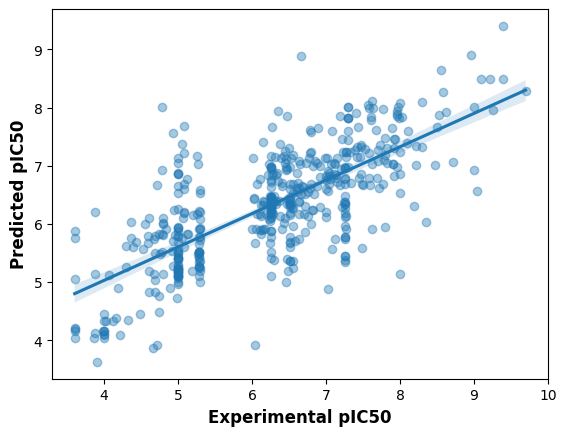

In [14]:
ax = sns.regplot(x=y_test_reg, y=y_pred_reg, scatter_kws={'alpha':0.4})
ax.set_xlabel('Experimental pIC50', fontsize='large', fontweight='bold')
ax.set_ylabel('Predicted pIC50', fontsize='large', fontweight='bold')
plt.show()

## **Y-Randomization – Validate Model**

In [15]:
n_iterations = 5
random_r2_scores = []

for i in range(n_iterations):
    y_train_shuffled = shuffle(y_train_reg, random_state=i)
    rf_random = RandomForestRegressor(n_estimators=200, random_state=42)
    rf_random.fit(X_train_reg, y_train_shuffled)
    y_pred_random = rf_random.predict(X_test_reg)
    r2_random = r2_score(y_test_reg, y_pred_random)
    random_r2_scores.append(r2_random)

print('\nY-Randomization Test Results:')
print(f'Mean R² with shuffled Y: {np.mean(random_r2_scores):.4f}')
print(f'Actual RF R²: {r2:.4f}')


Y-Randomization Test Results:
Mean R² with shuffled Y: -0.2383
Actual RF R²: 0.5220


### **Interpretation:**
- Actual RF R² = 0.5,   
- Random R² ≈ -0.2 → Model is learning real chemical patterns, not noise.

## **LazyPredict – Compare Multiple Regression Models**

In [16]:
print('\n' + '='*60)
print('LAZYPREDICT - COMPARING MULTIPLE REGRESSION MODELS')
print('='*60)

# Initialize LazyRegressor
reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)

# Fit all models
models, predictions = reg.fit(X_train_reg, X_test_reg, y_train_reg, y_test_reg)

# Display results
print(models.head(10))  # Top 10 models


LAZYPREDICT - COMPARING MULTIPLE REGRESSION MODELS


  0%|          | 0/42 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001622 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 453
[LightGBM] [Info] Number of data points in the train set: 1954, number of used features: 151
[LightGBM] [Info] Start training from score 6.250109
                               Adjusted R-Squared  R-Squared  RMSE  Time Taken
Model                                                                         
HistGradientBoostingRegressor                0.34       0.54  0.83        1.59
NuSVR                                        0.33       0.54  0.83        0.49
SVR                                          0.32       0.53  0.84        0.52
RandomForestRegressor                        0.31       0.52  0.85        2.86
LGBMRegressor                                0.30       0.52  0.85        0.31
KNeighborsRegressor                       

## **Visualize Top Models**

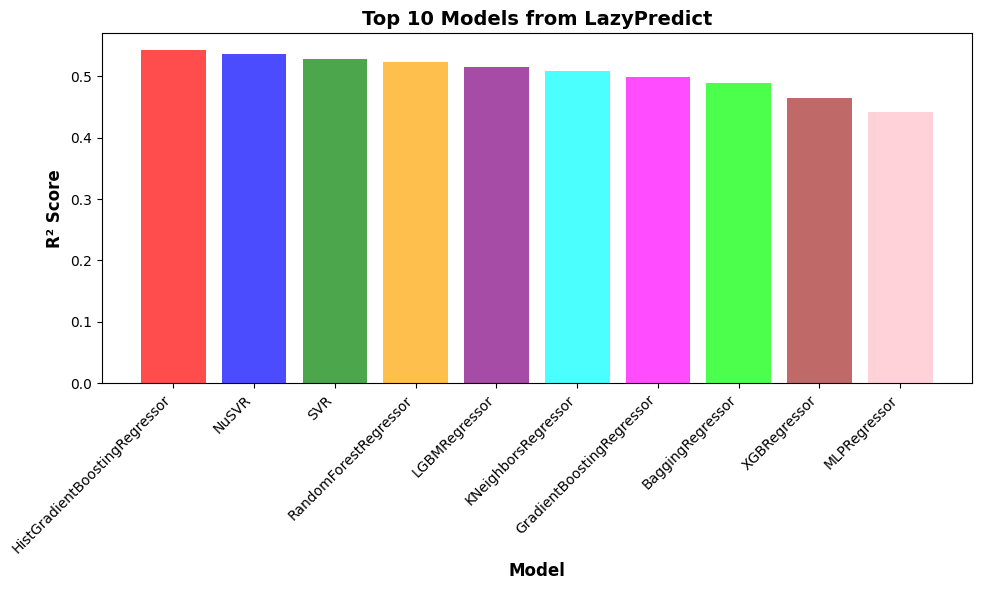

In [17]:
top_models = models.head(10)

plt.figure(figsize=(10, 6))

# Define distinct colors for each bar
colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'lime', 'brown', 'pink']

# Vertical bar plot with multiple colors and alpha for transparency
plt.bar(top_models.index, top_models['R-Squared'], color=colors, alpha=0.7)

plt.ylabel('R² Score', fontsize=12, fontweight='bold')
plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.title('Top 10 Models from LazyPredict', fontsize=14, fontweight='bold')

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## **Compare Best Model with Random Forest**

In [18]:
best_model_name = models.index[0]
best_r2 = models['R-Squared'].iloc[0]
print(f'Best model from LazyPredict: {best_model_name}')
print(f'Best R² score: {best_r2:.4f}')
print(f'Random Forest R²: {r2:.4f}')
print(f'Improvement: {(best_r2 - r2)*100:.2f}%')

# Check Random Forest rank
if 'RandomForestRegressor' in models.index:
    rf_rank = models.index.get_loc('RandomForestRegressor') + 1
    print(f'Random Forest ranked: {rf_rank} out of {len(models)}')

Best model from LazyPredict: HistGradientBoostingRegressor
Best R² score: 0.5428
Random Forest R²: 0.5220
Improvement: 2.08%
Random Forest ranked: 4 out of 42


## **Random Forest Feature Importances using SHAP values**

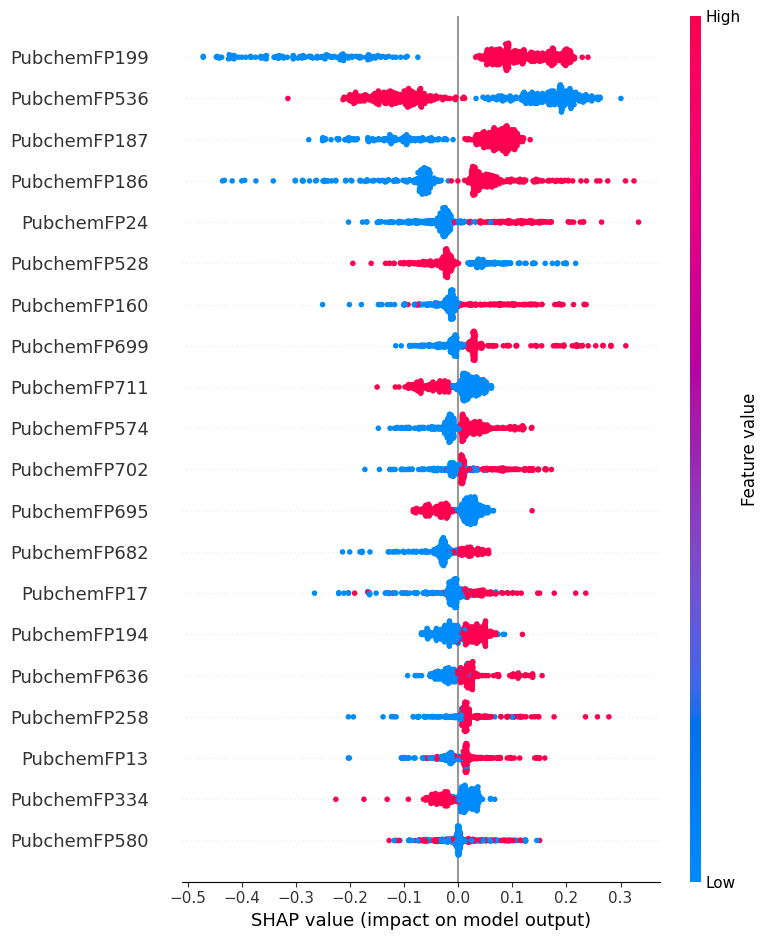

In [19]:
# Create an explainer and calculate SHAP values for the test set
explainer = shap.Explainer(rf_model)
shap_values = explainer(X_test_reg)

# Summary plot
shap.summary_plot(shap_values, X_test_reg, feature_names= feature_names)